# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation. 

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install datasets scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [2]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [3]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...
Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Sports      2074
Sci/Tech    2021
Business    1959
World       1946
Name: count, dtype: int64


In [4]:
# Preprocess
ag_train['text_clean'] = ag_train['text'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['text'].apply(preprocess_simple)

# TF-IDF Vectorization
# Configure vectorizer and create document-term matrices for train and test
tfidf_ag = TfidfVectorizer(
	max_features=10000,
	ngram_range=(1, 2),
	min_df=2,
	stop_words='english'
)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 10000


### Exercise A.1: Train a News Classifier

In [5]:
# TODO: Train a Logistic Regression classifier on AG News
# 1. Create the classifier
# 2. Train it
# 3. Make predictions
# 4. Calculate accuracy and F1-score (macro)

# YOUR CODE HERE
clf_ag = LogisticRegression(random_state=42)  # Create LogisticRegression

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8875
  F1 (macro): 0.8865


In [6]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.88      0.89       493
      Sports       0.93      0.96      0.95       504
    Business       0.86      0.82      0.84       474
    Sci/Tech       0.86      0.88      0.87       529

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [7]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...
Train: 1500, Test: 500

Columns: ['text', 'labels']


In [8]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [9]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [10]:
# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=4000,      # Choose: 3000-5000
    ngram_range=(1,2),       # Choose: (1,1), (1,2), or (1,3)
    min_df=3,            # Choose: 2-5
    max_df=0.95             # Choose: 0.9-0.99
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 4000


In [11]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(random_state=42)  # Create LinearSVC

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6332
  F1 (macro): 0.4884


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1. Accuracy comparison:
   - AG News: 0.8875 | Legal: 0.6332
   - Reason for difference: AG News has 4 well-separated topics (world/sports/business/sci-tech)
     with distinctive everyday vocabulary and short, clean texts, so the classes are easy to
     separate. Legal documents share a large block of boilerplate/legalese ("shall", "agreement",
     "party") across all contract types, the classes overlap (e.g. executive vs. employee
     agreements), and there's less training signal — so accuracy is much lower.

2. My vectorizer choices:
   - max_features=4000 because legal text has a large repetitive vocabulary; capping features
     keeps the most informative terms and avoids overfitting to rare boilerplate.
   - ngram_range=(1,2) because key legal concepts are multi-word phrases ("base salary",
     "credit agreement", "purchase agreement"), so bigrams add discriminative signal over unigrams.
   - min_df=3 because terms appearing in fewer than 3 documents are usually noise/typos and
     drop them to reduce dimensionality.
   - max_df=0.95 because words present in >95% of documents are shared legal boilerplate
     ("shall", "agreement") that carry no class-discriminating information.

3. Legal classification challenges:
   - Length: contracts are long and verbose, diluting class-specific signal among boilerplate.
   - Vocabulary: heavy domain-specific legalese with high term overlap across contract types.
   - Ambiguity: categories overlap (employment vs. executive agreements, loan vs. note),
     making clean boundaries hard and lowering accuracy.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [12]:
#!pip install datasets==3.6.0

In [20]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("SetFit/amazon_reviews_multi_en", trust_remote_code=True)

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")
print(amazon_train['label'].value_counts().sort_index())

Loading Amazon Reviews dataset...
Train: 5000, Test: 1000

Columns: ['id', 'text', 'label', 'label_text']

Star rating distribution:
label
0    1007
1     982
2    1003
3     987
4    1021
Name: count, dtype: int64


In [23]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['label'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['label'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4013, Test: 790

Sentiment distribution:
sentiment
0    2992
1    1021
Name: count, dtype: int64


In [25]:
# Show sample reviews (robust to differing column names)
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
# fallback to existing columns: product_category may not exist in this dataset
product_pos = pos_sample.get('product_category', pos_sample.get('label_text', pos_sample.get('id', 'N/A')))
review_pos = pos_sample.get('review_body', pos_sample.get('text', ''))
print(f"Product: {product_pos}")
print(f"Review: {review_pos[:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
product_neg = neg_sample.get('product_category', neg_sample.get('label_text', neg_sample.get('id', 'N/A')))
review_neg = neg_sample.get('review_body', neg_sample.get('text', ''))
print(f"Product: {product_neg}")
print(f"Review: {review_neg[:300]}...")

Sample POSITIVE review:
Product: 4
Review: These bags have a lot of space in them, good thing about these bags is that I can easily see what's inside then. Very reasonable price....


Sample NEGATIVE review:
Product: 2
Review: Not strong enough to run a small 120v vacuum cleaner, to clean car....


### Exercise B.1: Build Amazon Sentiment Classifier

In [27]:
# TODO: Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['text'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['text'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words='english'
)

X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: YOUR CODE HERE - Train Naive Bayes and evaluate or choose another model if not suitable
clf_amazon = MultinomialNB()  # Create MultinomialNB

# Train
clf_amazon.fit(X_train_amz, y_train_amz)

# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.8114

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      1.00      0.89       598
    Positive       0.98      0.23      0.37       192

    accuracy                           0.81       790
   macro avg       0.89      0.61      0.63       790
weighted avg       0.84      0.81      0.76       790



In [28]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['works great', 'great product', 'exactly wanted', 'lightweight', 'fast shipping', 'excellent', 'works like', 'quality price', 'exactly', 'great buy', 'great price', 'exactly needed', 'amazing', 'loves', 'highly recommend']

Top NEGATIVE words: ['return', 'broken', 'broke', 'waste', 'returned', 'cheap', 'disappointed', 'waste money', 'ok', 'poor', 'stopped', 'stopped working', 'didnt', 'started', 'returning']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [29]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("tweet_eval", "sentiment")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


Generating validation split: 100%|██████████| 2000/2000 [00:00<00:00, 724092.19 examples/s]


Train: 45615, Test: 12284

Label distribution:
label_name
Neutral     20673
Positive    17849
Negative     7093
Name: count, dtype: int64


In [30]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: So disappointed in wwe summerslam! I want to see john cena wins his 16th title

[Neutral]: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[Positive]: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"



In [31]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt @user in the original draft of the th book remus lupin survived the battle of hogwarts #happybirthdayremuslupin


### Exercise B.2: Build Twitter Sentiment Classifier

In [32]:
# TODO: Build a classifier using character n-grams (good for short, informal text)

# YOUR CODE HERE: Create a vectorizer with character n-grams
# Hint: Use analyzer='char_wb' for word-boundary-aware character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',           # 'char_wb' for character n-grams with word boundaries
    ngram_range=(2, 5),        # Try (2,5) or (3,6) for character n-grams
    max_features=5000,       # 3000-5000
    min_df=2              # 2-5
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [33]:
# TODO: Train Logistic Regression and evaluate

clf_tweet = LogisticRegression(random_state=42)  # YOUR CODE HERE

# Train and predict

y_pred_tw = clf_tweet.fit(X_train_tw, y_train_tw).predict(X_test_tw)

# Evaluate
print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw, y_pred_tw):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw, y_pred_tw, average='macro'):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_tw, y_pred_tw, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.5860
  F1 (macro): 0.5591

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.37      0.48      3972
     Neutral       0.59      0.72      0.65      5937
    Positive       0.50      0.61      0.55      2375

    accuracy                           0.59     12284
   macro avg       0.59      0.57      0.56     12284
weighted avg       0.60      0.59      0.58     12284



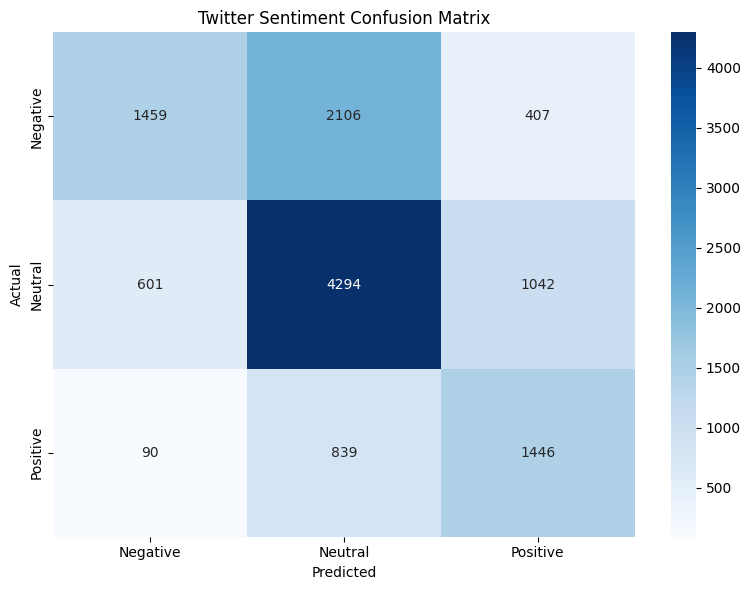

In [34]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task:
   - Amazon F1: 0.63 (macro) | Twitter F1: 0.56 (macro)
   - Reason: Twitter is harder. It's a 3-class problem (vs. Amazon's 2 classes), tweets are
     short, informal, and full of slang/sarcasm/hashtags, and the classes are imbalanced
     (Neutral 20,673 vs Negative 7,093 in train). Amazon reviews are longer and have clearer
     polarity cues, so its signal is easier to learn.

2. Character n-gram choices:
   - ngram_range=(2,5) because character n-grams of length 2–5 capture sub-word patterns,
     prefixes/suffixes and short slang ("luv", "soo", "gr8") while staying compact.
   - Advantage over words: robust to misspellings, slang, hashtags and out-of-vocabulary
     tokens common in tweets — a word-level model would treat "good", "gud", "goood" as
     unrelated, while char n-grams share overlapping substrings.

3. Most confused class:
   - Class: Negative (recall only 0.37 — frequently predicted as Neutral)
   - Reason: Negative is the smallest class (class imbalance), so the model is biased toward
     the majority Neutral class. Negative sentiment is also often subtle, sarcastic, or
     understated, making it look neutral on the surface.

4. Difficult tweet example:
   - Tweet: "Oh great, my new phone died after one day. Just what I needed. #blessed"
   - Why it's hard: it's sarcastic — positive words ("great", "#blessed") express negative
     sentiment. A bag-of-character-n-grams model has no context to detect irony, so it would
     likely misclassify this as Positive or Neutral.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [37]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")

# First try standard load (may fail with timeouts); fall back to streaming if needed
try:
	arxiv = load_dataset("scientific_papers", "arxiv", trust_remote_code=True)
	arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)
except Exception as e:
	print(f"Standard download failed ({type(e).__name__}): {e}\nFalling back to streaming and incremental load...")
	arxiv_stream = load_dataset("scientific_papers", "arxiv", split="train", streaming=True, trust_remote_code=True)
	rows = []
	for i, item in enumerate(arxiv_stream):
		rows.append(item)
		if i >= 1999:
			break
	arxiv_df = pd.DataFrame(rows)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


Standard download failed (FSTimeoutError): 
Falling back to streaming and incremental load...


Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [38]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 additive models play an important role in semiparametric statistics . 
 this paper gives learning rates for regularized kernel based methods for additive models . 
 these learning rates compare favourably in particular in high dimensions to recent results on optimal learning rates for purely nonparametric regularized kernel based quantile regression using the gaussian radial basis function kernel , provided the assumption of an additive model is valid . 
 additionally , a concrete example is pr


In [43]:
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
# configure vectorizer for LDA (count vectors, remove very rare terms, limit vocab size)
count_vec_arxiv = CountVectorizer(
	max_features=10000,
	ngram_range=(1, 2),
	min_df=5,
	max_df=0.95,
	stop_words='english'
)

dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

Document-term matrix: (2000, 6973)


In [50]:
# Train LDA model
# Choose number of topics for ArXiv (recommended 8-12). Set default to 10.
n_topics_arxiv = 10  # Scientific papers likely have diverse topics.

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print(f"Training LDA on ArXiv papers with {n_topics_arxiv} topics...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers with 10 topics...
Done!


In [51]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: quantum, state, qubit, gate, algorithm, measurement, classical, adiabatic, error, information, qubits, implementation
Topic 1: spin, phase, xmath, temperature, transition, field, phys, state, order, rev, magnetic, phys rev
Topic 2: galaxy, xmath, emission, source, disk, line, ray, cluster, high, region, star, gas
Topic 3: theory, gauge, loop, field, symmetry, closed, field theory, string, term, non abelian, non, boundary
Topic 4: photon, quantum, single, xcite, beam, state, laser, optical, cavity, phys, interference, single photon
Topic 5: planet, planetary, concurrence, entanglement, transit, price, pure state, detection, orbit, extrasolar, hat, fingerprint
Topic 6: twist, structure function, category, deuteron, proton neutron, function large, omitted, tensor product, continue, tensor, globular, previous work
Topic 7: xmath, mass, star, model, hole, black hole, density, black, ray, matter, binary, observed
Topic 8: xmath, xmath xmath, xcite, function

### Exercise C.1: Interpret ArXiv Topics

In [52]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
    0: "Quantum Computing & Information",
    1: "Condensed Matter: Magnetism & Phase Transitions",
    2: "Astrophysics: Galaxies & Emission",
    3: "Theoretical Physics: Gauge & String/Field Theory",
    4: "Quantum Optics & Photonics",
    5: "Exoplanets & Planetary Detection",
    6: "Nuclear/Particle Physics: Structure Functions",
    7: "Black Holes & Compact Objects",
    8: "Mathematical Methods & Equations",
    9: "General Physics: Models & Interactions",
    # Add more if n_topics_arxiv > 8
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Topic Interpretations:
  Topic 0: Quantum Computing & Information
  Topic 1: Condensed Matter: Magnetism & Phase Transitions
  Topic 2: Astrophysics: Galaxies & Emission
  Topic 3: Theoretical Physics: Gauge & String/Field Theory
  Topic 4: Quantum Optics & Photonics
  Topic 5: Exoplanets & Planetary Detection
  Topic 6: Nuclear/Particle Physics: Structure Functions
  Topic 7: Black Holes & Compact Objects
  Topic 8: Mathematical Methods & Equations
  Topic 9: General Physics: Models & Interactions


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [53]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("albertvillanova/legal_contracts", split="train", streaming=True)

# Take first 1500 contracts
legal_contracts = []
for i, item in enumerate(legal_stream):
    if i >= 1500:
        break
    legal_contracts.append(item)

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...
Loaded 1500 contracts


In [54]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [55]:
# TODO: Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3,
    stop_words='english'
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 5000)


In [56]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 8  # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [57]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, company, employment, shall, executive shall, agreement, salary, benefit, base salary, termination, base, bonus
Topic 1: borrower, loan, credit, lender, agreement, credit agreement, bank, agent, amendment, section, loan agreement, administrative agent
Topic 2: option, plan, stock, share, committee, participant, award, shall, company, common stock, mean, stock option
Topic 3: seller, buyer, agreement, purchase, purchaser, shall, party, share, closing, product, purchase agreement, property
Topic 4: employee, company, employment, agreement, shall, employee shall, termination, bonus, employer, employment agreement, salary, employee employment
Topic 5: tenant, landlord, lease, rent, premise, lessee, building, lessor, shall, term, base rent, area
Topic 6: company, voting, change control, control, business combination, change, security, director, voting security, board, combination, person
Topic 7: note, maker, principal, shall, holder

In [60]:
# TODO: Assign labels to legal topics

my_legal_topic_labels = {}  # Add your labels: {0: "label", 1: "label", ...}
labels = {
    0: "Executive Employment Agreements",
    1: "Loan & Credit Agreements",
    2: "Stock Option & Equity Plans",
    3: "Purchase & Sale Agreements",
    4: "General Employee Employment Agreements",
    5: "Lease / Rental Agreements",
    6: "Change-of-Control / Voting & Governance",
    7: "Promissory Notes",
}
# YOUR CODE HERE - fill the dictionary
for i in range(n_topics_legal):
    my_legal_topic_labels[i] = labels[i]  # Replace with your labels

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Executive Employment Agreements
  Topic 1: Loan & Credit Agreements
  Topic 2: Stock Option & Equity Plans
  Topic 3: Purchase & Sale Agreements
  Topic 4: General Employee Employment Agreements
  Topic 5: Lease / Rental Agreements
  Topic 6: Change-of-Control / Voting & Governance
  Topic 7: Promissory Notes


### Exercise C.3: Topic Distribution Visualization

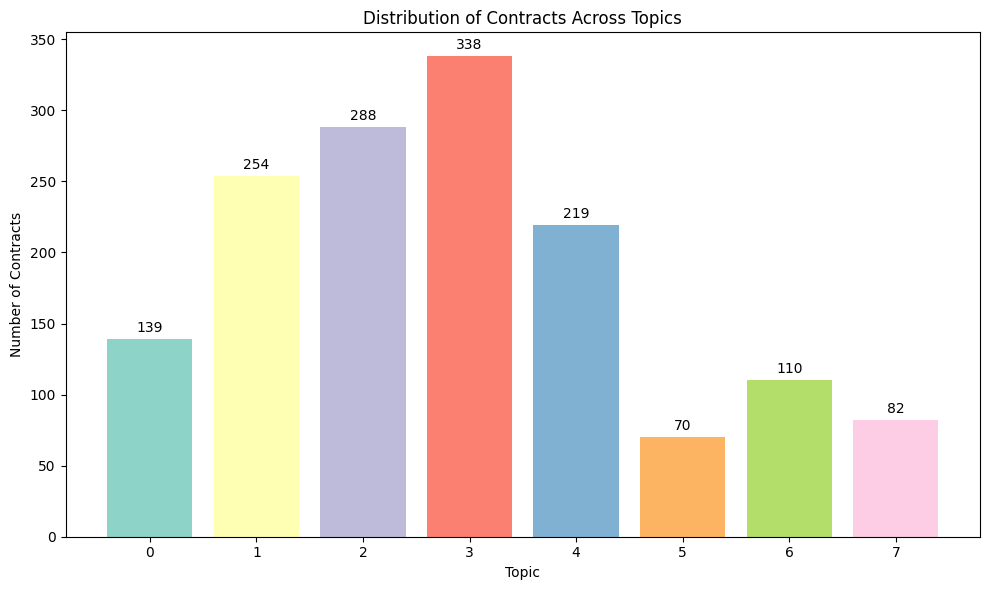

In [61]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. Easier to interpret:
   - Domain: ...
   - Reason: ...

2. Legal topic distribution:
   - Balanced? ...
   - What this indicates: ...

3. Topic refinement suggestions:
   - ArXiv - Merge: Topics ___ and ___ because...
   - ArXiv - Split: Topic ___ because...
   - Legal - Merge: Topics ___ and ___ because...
   - Legal - Split: Topic ___ because...

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [x] All code exercises completed (fill all `___` placeholders)
- [x] **All written questions answered with YOUR personal interpretation**
- [x] All visualizations saved (PNG files)
- [x] Notebook saved
- [x] Pushed to Git repository
- [x] **Repository link sent to: yoroba93@gmail.com**
